In [ ]:
%pip install beautifulsoup4
%pip install contractions
%pip install joblib
%pip install kaleido
%pip install langdetect
%pip install matplotlib
%pip install nltk
%pip install numpy
%pip install optuna
%pip install pandas
%pip install plotly
%pip install scikit-learn
%pip install seaborn
%pip install spacy
%pip install spacymoji
%pip install wordcloud

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pickle
import re
import string
import sys
import time
import unicodedata
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import spacymoji
from mpl_toolkits.mplot3d import Axes3D
from spacy import displacy
from spacy.lang.fr import French
from spacy.tokenizer import _get_regex_pattern
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objs as go
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as py
from plotly.subplots import make_subplots

import nltk
from nltk import pos_tag, sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("tagsets")
nltk.download("tagsets_json")
nltk.download("wordnet")

import sklearn
from sklearn import metrics
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

import optuna
import contractions
from bs4 import BeautifulSoup
from langdetect import detect

!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))

## 🚀 Run from here

In [155]:
df=pd.read_csv('scitweets_export.tsv',sep='\t')
print (df.head())

   Unnamed: 0            tweet_id  \
0           0  316669998137483264   
1           1  319090866545385472   
2           2  322030931022065664   
3           3  322694830620807168   
4           4  328524426658328576   

                                                text  science_related  \
0  Knees are a bit sore. i guess that's a sign th...                0   
1          McDonald's breakfast stop then the gym 🏀💪                0   
2  Can any Gynecologist with Cancer Experience ex...                1   
3  Couch-lock highs lead to sleeping in the couch...                1   
4  Does daily routine help prevent problems with ...                1   

   scientific_claim  scientific_reference  scientific_context  
0               0.0                   0.0                 0.0  
1               0.0                   0.0                 0.0  
2               1.0                   0.0                 0.0  
3               1.0                   0.0                 0.0  
4               1.

In [156]:
def normalize(X,
              removelowercase=False,
              removestopwords=False,
              removedigit=False,
              removeemoji=False,
              getstemmer=False,
              getlemmatisation=False):
    
    nlp = spacy.load("en_core_web_sm")
    nlp.add_pipe("emoji", first=True)
    re_token_match = spacy.tokenizer._get_regex_pattern(nlp.Defaults.token_match)
    re_token_match = f"({re_token_match}|#\w+|\w+-\w+)"
    X = contractions.fix(X)
    
    if removelowercase:
        X = X.lower()
    
    doc = nlp(X)
    
    lem = WordNetLemmatizer()
    stemmer = PorterStemmer()
    
    tokens = []
    
    for t in doc:
        if t.is_punct or t.is_space:
            continue
        if removestopwords and t.is_stop:
            continue
        if removedigit and t.like_num:
            continue
        if removeemoji and t._.is_emoji:
            continue
        
        word = t.text
        if getlemmatisation:
            word = lem.lemmatize(word)
        if getstemmer:
            word = stemmer.stem(word)
            
        tokens.append(word)
    
    return " ".join(tokens)   

In [157]:
class TextNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self,
              removelowercase=False,
              removestopwords=False,
              removedigit=False,
              removeemoji=False,
              getstemmer=False,
              getlemmatisation=False):
        
        self.removelowercase = removelowercase
        self.removestopwords = removestopwords
        self.removedigit = removedigit
        self.removeemoji = removeemoji
        self.getstemmer = getstemmer
        self.getlemmatisation = getlemmatisation
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        return [
            normalize(text,
            removelowercase=self.removelowercase,
            removestopwords=self.removestopwords,
            removedigit=self.removedigit,
            removeemoji=self.removeemoji,
            getstemmer=self.getstemmer,
            getlemmatisation=self.getlemmatisation)
            for text in X
        ]

In [158]:
X = df.text
y = df.scientific_claim

# Pipeline : pré-traitement puis vectorisation TF-IDF
pipe = Pipeline([
    ("cleaner", TextNormalizer()),
    ("vectorizer", TfidfVectorizer())
])

# Transformation des données
X_transformed = pipe.fit_transform(X)

# Création du DataFrame
df_pipe = pd.DataFrame(
    X_transformed.toarray(),
    columns=pipe["vectorizer"].get_feature_names_out()
)

print("Dimensions de la matrice TF-IDF :", df_pipe.shape, "\n")

# Affichage des premières colonnes pour inspection
print("Aperçu du résultat :")
print(df_pipe.iloc[:, :10])

Dimensions de la matrice TF-IDF : (1140, 7923) 

Aperçu du résultat :
           000   01  049  07904567432a  093  0cmzimdaje  0hitnsx0c4  \
0     0.000000  0.0  0.0           0.0  0.0         0.0         0.0   
1     0.000000  0.0  0.0           0.0  0.0         0.0         0.0   
2     0.000000  0.0  0.0           0.0  0.0         0.0         0.0   
3     0.000000  0.0  0.0           0.0  0.0         0.0         0.0   
4     0.000000  0.0  0.0           0.0  0.0         0.0         0.0   
...        ...  ...  ...           ...  ...         ...         ...   
1135  0.000000  0.0  0.0           0.0  0.0         0.0         0.0   
1136  0.000000  0.0  0.0           0.0  0.0         0.0         0.0   
1137  0.000000  0.0  0.0           0.0  0.0         0.0         0.0   
1138  0.292443  0.0  0.0           0.0  0.0         0.0         0.0   
1139  0.000000  0.0  0.0           0.0  0.0         0.0         0.0   

      0iwaxgdpww  0jlkmseyhp  0oup8eayxh  
0            0.0         0.0      

In [159]:
def plot_pca_2d_3d(X, y, title_2d="ACP 2D", title_3d="ACP 3D"):
    """
    Affiche une ACP 2D et 3D pour visualiser la répartition des documents.

    X : matrice de features (numpy array ou matrice creuse)
    y : labels (array-like)
    """

    # Conversion si matrice creuse
    X_dense = X.toarray() if hasattr(X, "toarray") else X
    y = np.array(y)

    # ACP 2D
    pca_2d = PCA(n_components=2, random_state=0)
    X_pca_2d = pca_2d.fit_transform(X_dense)

    # ACP 3D
    pca_3d = PCA(n_components=3, random_state=0)
    X_pca_3d = pca_3d.fit_transform(X_dense)

    # Figure
    fig = plt.figure(figsize=(12, 5))

    # ----- Plot 2D -----
    ax1 = fig.add_subplot(1, 2, 1)
    idx0 = (y == 0)
    idx1 = (y == 1)

    ax1.scatter(X_pca_2d[idx0, 0], X_pca_2d[idx0, 1],
                alpha=0.6, label="Avis négatifs")
    ax1.scatter(X_pca_2d[idx1, 0], X_pca_2d[idx1, 1],
                alpha=0.6, label="Avis positifs")

    ax1.set_title(title_2d)
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    ax1.legend()

    # ----- Plot 3D -----
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.scatter(X_pca_3d[idx0, 0], X_pca_3d[idx0, 1], X_pca_3d[idx0, 2],
                alpha=0.6, label="Avis négatifs")
    ax2.scatter(X_pca_3d[idx1, 0], X_pca_3d[idx1, 1], X_pca_3d[idx1, 2],
                alpha=0.6, label="Avis positifs")

    ax2.set_title(title_3d)
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_zlabel("PC3")

    plt.tight_layout()
    plt.show()

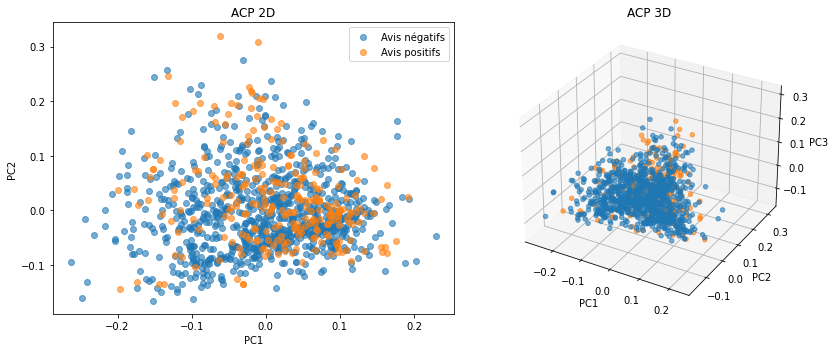

In [160]:
plot_pca_2d_3d(X_transformed, df["scientific_claim"])